##**RQ3: How much of the variance in sale price is attributable to neighbourhood, and what location-specific factors explain price differences across neighbourhoods?**



**Thomas Erhart i6374836**

Step 1: Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

sns.set_theme(style="whitegrid", palette="muted")

Step 2: Load Data

In [2]:
df = pd.read_csv("ames.csv")

The Ames Housing dataset contains 2,930 house sales in Ames, Iowa between 2006 and 2010. Each row represents one sale with 81 variables covering the physical characteristics, location, and sale conditions of each property.

Step 3: Missing values

In [3]:
print(df.isna().sum())

# missing values in Mas_Vnr_Type and Misc_Feature --> the house doesn't have that feature
df["Mas_Vnr_Type"]  = df["Mas_Vnr_Type"].fillna("None")
df["Misc_Feature"]  = df["Misc_Feature"].fillna("None")

MS_SubClass       0
MS_Zoning         0
Lot_Frontage      0
Lot_Area          0
Street            0
                 ..
Sale_Type         0
Sale_Condition    0
Sale_Price        0
Longitude         0
Latitude          0
Length: 74, dtype: int64


Step 4: Duplicates

In [ ]:
# duplicates
print(df.duplicated().sum())
# no duplicates

0


Step 5: Descriptive Statistics

In [ ]:
KEY_COLS = ["Sale_Price", "Lot_Area", "Gr_Liv_Area",
            "Lot_Frontage", "Total_Bsmt_SF", "Garage_Area"]
df[KEY_COLS].describe().round(1)

,Sale_Price,Lot_Area,Gr_Liv_Area,Lot_Frontage,Total_Bsmt_SF,Garage_Area
count,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0
mean,180796.1,10147.9,1499.7,57.6,1051.3,472.7
std,79886.7,7880.0,505.5,33.5,441.0,215.2
min,12789.0,1300.0,334.0,0.0,0.0,0.0
25%,129500.0,7440.2,1126.0,43.0,793.0,320.0
50%,160000.0,9436.5,1442.0,63.0,990.0,480.0
75%,213500.0,11555.2,1742.8,78.0,1301.5,576.0
max,755000.0,215245.0,5642.0,313.0,6110.0,1488.0


Step 6: Checking for outliers

In [ ]:
# outlier check
q1  = df["Sale_Price"].quantile(0.25)
q3  = df["Sale_Price"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df["Sale_Price"] < lower) | (df["Sale_Price"] > upper)]
print(len(outliers))
# keeping them - real transactions not errors

# remove likely house transfers (large houses sold well below market value)
mask = (df["Gr_Liv_Area"] > 4000) & (df["Sale_Price"] < 300000)
print(f"Removed {mask.sum()} data points identified as likely house transfers")
df = df[~mask].reset_index(drop=True)

137
Removed 3 data points identified as likely house transfers


The IQR method identified a number of sale price outliers. These were kept in the analysis as they represent genuine market transactions rather than data entry errors. However, three observations with very large living areas (over 4,000 sq ft) but unusually low sale prices (under $300,000) were removed as these likely represent non-market transfers such as family sales rather than open market transactions.

Step 7: Defining variables and adjusting to inflation

In [ ]:
TARGET = "Sale_Price"
TARGET_ADJ = "Sale_Price_Adj"

# location features
NUMERIC_LOCATION = ["Lot_Frontage", "Lot_Area", "Longitude", "Latitude"]
CATEGORICAL_LOCATION = ["MS_Zoning", "Condition_1", "Condition_2"]

# CPI from BLS, adjusting to 2010 dollars
CPI = {2006: 201.6, 2007: 207.342, 2008: 215.303, 2009: 214.537, 2010: 218.056}
BASE_YEAR = 2010

df["CPI_year"]      = df["Year_Sold"].map(CPI)
df[TARGET_ADJ]      = df[TARGET] * (CPI[BASE_YEAR] / df["CPI_year"])

print(f"Neighbourhoods: {df['Neighborhood'].nunique()} unique values")
print(f"\nInflation adjustment (base year = {BASE_YEAR}, US CPI):")
for yr, cpi in CPI.items():
    factor = CPI[BASE_YEAR] / cpi
    mean_nom = df.loc[df.Year_Sold == yr, TARGET].mean()
    mean_adj = df.loc[df.Year_Sold == yr, TARGET_ADJ].mean()
    print(f"  {yr}  CPI={cpi:.1f}  factor={factor:.4f}  "
          f"mean nominal=${mean_nom:,.0f}  → adjusted=${mean_adj:,.0f}")
print(f"overall mean nominal: ${df[TARGET].mean():,.0f}")
print(f"overall mean adjusted: ${df[TARGET_ADJ].mean():,.0f}")

Neighbourhoods: 28 unique values

Inflation adjustment (base year = 2010, US CPI):
  2006  CPI=201.6  factor=1.0816  mean nominal=$181,762  → adjusted=$196,598
  2007  CPI=207.3  factor=1.0517  mean nominal=$185,141  → adjusted=$194,707
  2008  CPI=215.3  factor=1.0128  mean nominal=$178,872  → adjusted=$181,159
  2009  CPI=214.5  factor=1.0164  mean nominal=$181,405  → adjusted=$184,380
  2010  CPI=218.1  factor=1.0000  mean nominal=$172,598  → adjusted=$172,598
overall mean nominal: $180,801
overall mean adjusted: $187,375


The dataset spans 2006–2010, a period that includes the US housing crash. To ensure prices are comparable across years, all sale prices are adjusted to 2010 dollars using the US Consumer Price Index (CPI) from the Bureau of Labor Statistics. The adjustment multiplies each nominal price by the ratio of the 2010 CPI to the CPI in the year of sale. For example, a house sold in 2006 gets multiplied by 218.056 / 201.6 = 1.082, inflating it to 2010 dollars. Without this adjustment, a house sold in 2006 would appear cheaper than an identical house sold in 2010 simply due to general inflation rather than any real difference in value.

Step 8: Neighbourhood Breakdown

In [ ]:
neigh_stats = (
    df.groupby("Neighborhood")[TARGET_ADJ]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("mean", ascending=False)
    .round(0)
)
print(neigh_stats.to_string())

overall_mean = df[TARGET_ADJ].mean()
neigh_stats["pct_above_avg"] = ((neigh_stats["mean"] - overall_mean) / overall_mean * 100).round(1)
top3 = neigh_stats.head(3)
bot3 = neigh_stats.tail(3)
print(f"\nTop 3 neighbourhoods (above avg %): \n{top3[['mean', 'pct_above_avg']]}")
print(f"\nBottom 3 neighbourhoods (above avg %): \n{bot3[['mean', 'pct_above_avg']]}")

                                         count      mean    median       std
Neighborhood                                                                
Northridge                                  71  343303.0  319028.0  109217.0
Stone_Brook                                 51  338771.0  336430.0  128481.0
Northridge_Heights                         166  333455.0  330706.0   98482.0
Green_Hills                                  2  297913.0  297913.0   69493.0
Veenker                                     24  258438.0  258408.0   70013.0
Timberland                                  72  255178.0  244137.0   72599.0
Somerset                                   182  237491.0  231663.0   59980.0
Clear_Creek                                 44  215833.0  205509.0   53191.0
Crawford                                   103  215499.0  210917.0   67540.0
College_Creek                              267  209375.0  209836.0   56268.0
Bloomington_Heights                         28  206033.0  194256.0   34814.0

There are 28 neighbourhoods in the dataset. The most expensive on average is Northridge at \$343,303 (83% above the overall mean of \$187,375). The cheapest is Meadow_Village at $99,415 (47% below average). This large spread already suggests that neighbourhood is a strong predictor of sale price. The top three neighbourhoods (Northridge, Stone_Brook, Northridge_Heights) are all in the north of Ames, while the bottom three (Briardale, Iowa_DOT_and_Rail_Road, Meadow_Village) are in lower-density or industrial-adjacent areas.

Step 9: Correlation Analysis

In [ ]:
# correlation
print("Numeric location features vs. Sale_Price:\n")

correlations = {}
for col in NUMERIC_LOCATION:
    r = df[col].corr(df[TARGET_ADJ])
    correlations[col] = r
    direction = "positive" if r > 0 else "negative"
    strength = "strong" if abs(r) > 0.5 else ("moderate" if abs(r) > 0.3 else "weak")
    print(f"  {col:<20} r = {r:+.3f}  ({strength} {direction})")

best_numeric = max(correlations, key=lambda k: abs(correlations[k]))
print(f"\n  Strongest numeric predictor: {best_numeric} (r = {correlations[best_numeric]:+.3f})")

# correlation matrix
print("\nCorrelation matrix among numeric location features + Sale_Price_Adj:")
corr_matrix = df[NUMERIC_LOCATION + [TARGET_ADJ]].corr().round(3)
print(corr_matrix.to_string())

Numeric location features vs. Sale_Price:

  Lot_Frontage         r = +0.205  (weak positive)
  Lot_Area             r = +0.271  (weak positive)
  Longitude            r = -0.250  (weak negative)
  Latitude             r = +0.291  (weak positive)

  Strongest numeric predictor: Latitude (r = +0.291)

Correlation matrix among numeric location features + Sale_Price_Adj:
                Lot_Frontage  Lot_Area  Longitude  Latitude  Sale_Price_Adj
Lot_Frontage           1.000     0.116     -0.017     0.051           0.205
Lot_Area               0.116     1.000     -0.094    -0.032           0.271
Longitude             -0.017    -0.094      1.000     0.029          -0.250
Latitude               0.051    -0.032      0.029     1.000           0.291
Sale_Price_Adj         0.205     0.271     -0.250     0.291           1.000


Pearson's r measures the linear relationship between each numeric location feature and the adjusted sale price, ranging from -1 (perfect negative) to +1 (perfect positive). None of the numeric location features show a strong correlation with price on their own. Latitude has the highest at r = +0.291 (moderate positive), meaning houses further north in Ames tend to sell for more. Lot_Area is r = +0.271, Longitude is r = -0.250 (negative because moving east in Ames moves toward less expensive areas), and Lot_Frontage is the weakest at r = +0.205. These moderate correlations suggest that raw coordinates and plot size alone do not capture price differences well — neighbourhood label is likely doing more of the work, which the regression will confirm.

Step 10: Regression Models

In [ ]:
# regression models

y = df[TARGET_ADJ].values  # use inflation-adjusted prices throughout regression

# one-hot encode categorical columns
def encode_categoricals(dataframe, cat_cols):
    enc = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
    encoded = enc.fit_transform(dataframe[cat_cols])
    feature_names = enc.get_feature_names_out(cat_cols)
    return encoded, feature_names, enc

# Model A: Neighbourhood only
print("\nModel A: Neighbourhood dummies only")

X_neigh_enc, neigh_feat_names, neigh_enc = encode_categoricals(df, ["Neighborhood"])

model_a = LinearRegression()
model_a.fit(X_neigh_enc, y)
y_pred_a = model_a.predict(X_neigh_enc)

r2_a = r2_score(y, y_pred_a)
rmse_a = np.sqrt(mean_squared_error(y, y_pred_a))

# cross validate
cv_r2_a = cross_val_score(LinearRegression(), X_neigh_enc, y, cv=5, scoring="r2")

print(f"R2 (train): {r2_a:.4f}")
print(f"RMSE: ${rmse_a:,.0f}")
print(f"CV R2 (5-fold): {cv_r2_a.mean():.4f} +/- {cv_r2_a.std():.4f}")

# Model B: Neighbourhood + numeric location features
print("\nModel B: Neighbourhood + location features")

X_loc_cat_enc, loc_cat_feat_names, _ = encode_categoricals(df, CATEGORICAL_LOCATION)

X_numeric = df[NUMERIC_LOCATION].values

X_full = np.hstack([X_neigh_enc, X_numeric, X_loc_cat_enc])
full_feat_names = list(neigh_feat_names) + NUMERIC_LOCATION + list(loc_cat_feat_names)

model_b = LinearRegression()
model_b.fit(X_full, y)
y_pred_b = model_b.predict(X_full)

r2_b = r2_score(y, y_pred_b)
rmse_b = np.sqrt(mean_squared_error(y, y_pred_b))

cv_r2_b = cross_val_score(LinearRegression(), X_full, y, cv=5, scoring="r2")

print(f"R2 (train): {r2_b:.4f}")
print(f"RMSE: ${rmse_b:,.0f}")
print(f"CV R2 (5-fold): {cv_r2_b.mean():.4f} +/- {cv_r2_b.std():.4f}")

r2_gain = r2_b - r2_a
print(f"R2 gain: +{r2_gain*100:.1f} pp")


Model A: Neighbourhood dummies only
R2 (train): 0.5702
RMSE: $54,604
CV R2 (5-fold): 0.5506 +/- 0.0208

Model B: Neighbourhood + location features
R2 (train): 0.6259
RMSE: $50,941
CV R2 (5-fold): 0.5928 +/- 0.0346
R2 gain: +5.6 pp


Two multiple linear regression models are estimated. Model A uses only neighbourhood dummy variables (one-hot encoded, with one neighbourhood dropped as baseline to avoid multicollinearity). Model B adds the numeric location features and categorical proximity/zoning variables on top.


Model A results: R^2 = 0.5702, meaning neighbourhood alone explains 57% of the variance in adjusted sale prices. The cross-validated R^2 is 0.5506, very close to the training R^2, which confirms the result is not overfitting — it generalises well to unseen data. The RMSE of \$54,604 means predictions are on average about \$55k off from actual prices.


Model B results: R^2 = 0.6259, meaning adding zoning, proximity conditions, and coordinates raises explained variance to 63%. The R^2 gain is +5.6 percentage points. Cross-validated R^2 is 0.5928. The RMSE drops to \$50,941.


Answer to the research question: Neighbourhood alone accounts for 57% of the variance in sale prices. The other location factors (plot size, coordinates, zoning, proximity to roads and features) add a further 5.6 percentage points, bringing the total to 63%.

Step 11: Coefficients

In [ ]:
#  Neighbourhood coefficients from Model A
print("\nneighbourhood coefficients:")

neigh_coefs = pd.Series(model_a.coef_, index=neigh_feat_names)
neigh_coefs = neigh_coefs.sort_values(ascending=False)

print("\n  Top 5 (price premium vs. baseline):")
for name, coef in neigh_coefs.head(5).items():
    label = name.replace("Neighborhood_", "")
    print(f"    {label:<40} +${coef:,.0f}")

print("\n  Bottom 5 (price discount vs. baseline):")
for name, coef in neigh_coefs.tail(5).items():
    label = name.replace("Neighborhood_", "")
    print(f"    {label:<40} ${coef:,.0f}")

# Location feature coefficients from Model B
print("\nlocation feature coefficients:")
coef_series = pd.Series(model_b.coef_, index=full_feat_names)

print("\n  Numeric location features:")
for feat in NUMERIC_LOCATION:
    c = coef_series[feat]
    print(f"    {feat:<25} coefficient = {c:+.2f}")

# Top categorical location coefficients
print("\n  Top 5 categorical location predictors by absolute coefficient:")
cat_coef = coef_series[[f for f in full_feat_names if f not in NUMERIC_LOCATION
                         and not f.startswith("Neighborhood_")]]
cat_coef_abs = cat_coef.abs().sort_values(ascending=False).head(5)
for feat in cat_coef_abs.index:
    print(f"    {feat:<50} {coef_series[feat]:+,.0f}")



neighbourhood coefficients:

  Top 5 (price premium vs. baseline):
    Northridge                               +$137,270
    Stone_Brook                              +$132,737
    Northridge_Heights                       +$127,421
    Green_Hills                              +$91,880
    Veenker                                  +$52,405

  Bottom 5 (price discount vs. baseline):
    Brookside                                $-77,266
    Old_Town                                 $-77,694
    Briardale                                $-96,242
    Iowa_DOT_and_Rail_Road                   $-98,301
    Meadow_Village                           $-106,618

location feature coefficients:

  Numeric location features:
    Lot_Frontage              coefficient = +227.48
    Lot_Area                  coefficient = +1.80
    Longitude                 coefficient = -227511.26
    Latitude                  coefficient = +766616.46

  Top 5 categorical location predictors by absolute coefficient:
    C

The neighbourhood coefficients from Model A show the price premium or discount for each neighbourhood relative to the baseline (Blmngtn, the first alphabetically after one-hot encoding drops it). The top five premium neighbourhoods are Northridge (+\$137,270), Stone_Brook (+\$132,737), Northridge_Heights (+\$127,421), Green_Hills (+\$91,880), and Veenker (+\$52,405). The biggest discounts are in Meadow_Village (-\$106,618), Iowa_DOT_and_Rail_Road (-\$98,301), and Briardale (-\$96,242).


From Model B, each additional foot of street frontage adds \$227 to predicted price, and each additional square foot of lot area adds \$1.80. The Latitude coefficient is +\$766,616 — this is large because latitude varies over a very small range (41.99 to 42.06 degrees), so a one-unit change in latitude is meaningless; what matters is the direction (positive = north = more expensive). The strongest categorical predictors are proximity to positive features: being adjacent to a positive feature (PosA) adds \$186,086, and residential zoning classifications also command significant premiums over the baseline commercial/industrial zones.

Chart 1: Mean sale price by neighbourhood adjusted to inflation

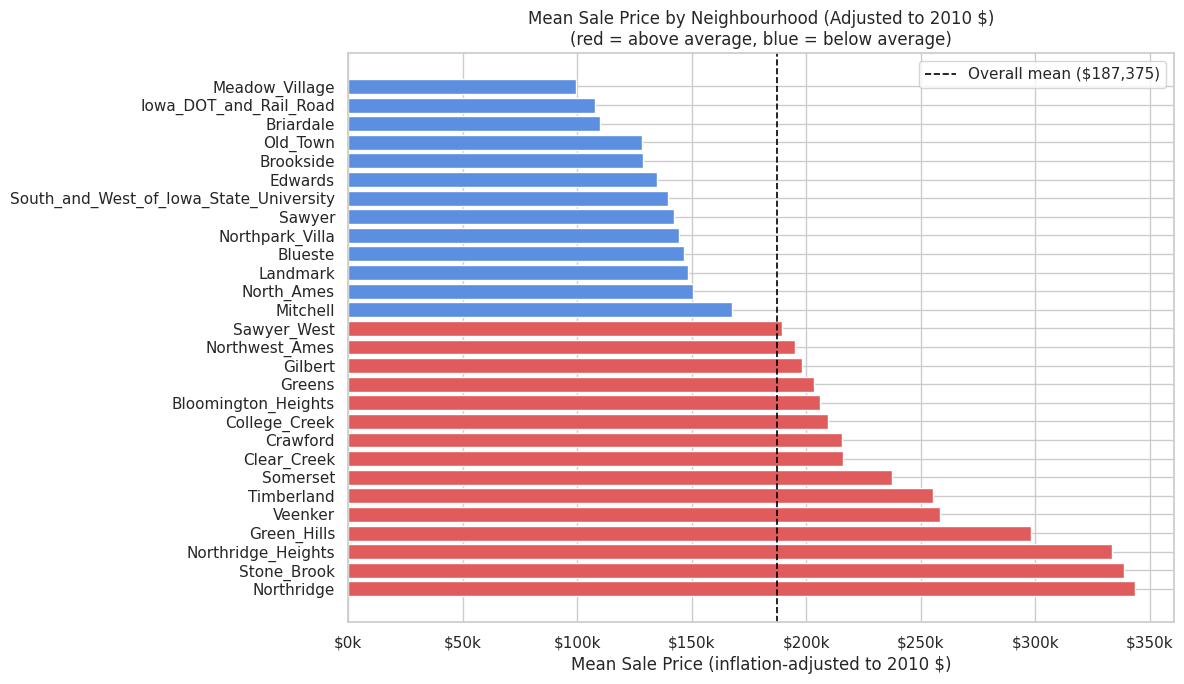

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#e05c5c" if m > overall_mean else "#5c8fe0" for m in neigh_stats["mean"]]
ax.barh(neigh_stats.index, neigh_stats["mean"], color=colors)
ax.axvline(overall_mean, color="black", linestyle="--", linewidth=1.2,
           label=f"Overall mean (${overall_mean:,.0f})")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel(f"Mean Sale Price (inflation-adjusted to {BASE_YEAR} $)")
ax.set_title(f"Mean Sale Price by Neighbourhood (Adjusted to {BASE_YEAR} $)\n"
             "(red = above average, blue = below average)")
ax.legend()
plt.tight_layout()
plt.show()

Chart 2: Correlation Heatmap

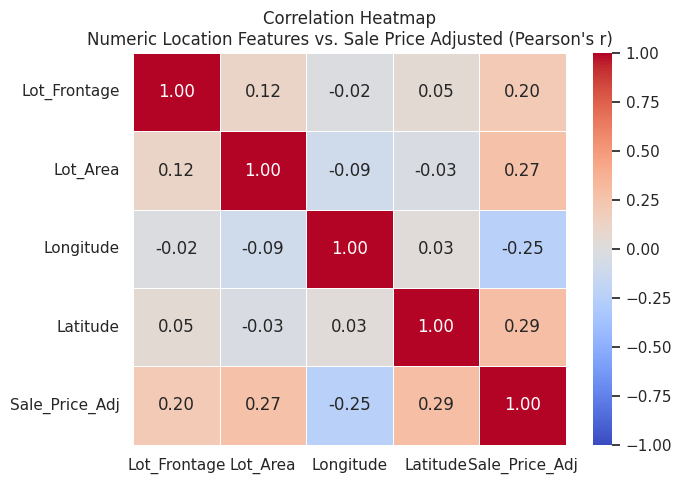

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title(f"Correlation Heatmap\n"
             f"Numeric Location Features vs. Sale Price Adjusted (Pearson's r)")
plt.tight_layout()
plt.show()

Chart 3: Latitude vs. Sale price

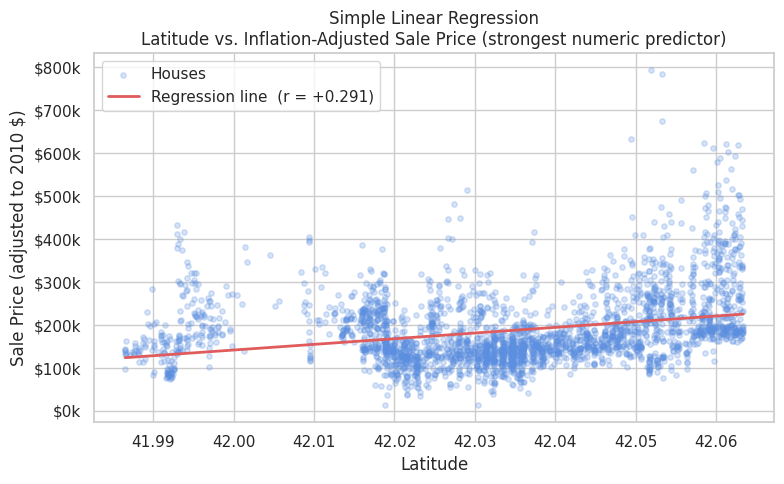

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Latitude"], df[TARGET_ADJ], alpha=0.25, s=15, color="#5c8fe0", label="Houses")
lat_vals = df["Latitude"].values.reshape(-1, 1)
lr = LinearRegression().fit(lat_vals, y)
x_line = np.linspace(df["Latitude"].min(), df["Latitude"].max(), 200).reshape(-1, 1)
ax.plot(x_line, lr.predict(x_line), color="#e05c5c", linewidth=2,
        label=f"Regression line  (r = {correlations['Latitude']:+.3f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel("Latitude")
ax.set_ylabel(f"Sale Price (adjusted to {BASE_YEAR} $)")
ax.set_title("Simple Linear Regression\n"
             f"Latitude vs. Inflation-Adjusted Sale Price (strongest numeric predictor)")
ax.legend()
plt.tight_layout()
plt.show()

Chart 4: Comparison between regression models

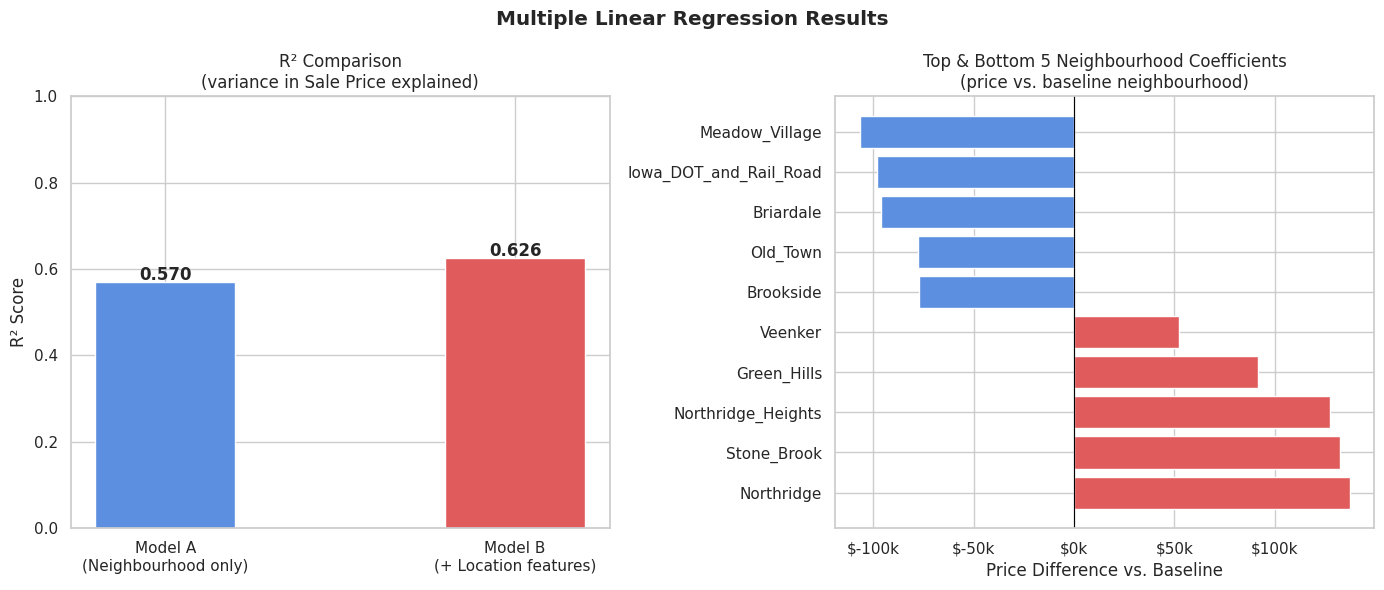

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_labels = ["Model A\n(Neighbourhood only)", "Model B\n(+ Location features)"]
r2_vals = [r2_a, r2_b]
bar_colors = ["#5c8fe0", "#e05c5c"]
axes[0].bar(model_labels, r2_vals, color=bar_colors, width=0.4)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("R² Score")
axes[0].set_title("R² Comparison\n(variance in Sale Price explained)")

top5 = neigh_coefs.head(5)
bot5 = neigh_coefs.tail(5)
coef_plot = pd.concat([top5, bot5])
coef_plot.index = [i.replace("Neighborhood_", "") for i in coef_plot.index]
bar_c = ["#e05c5c" if v > 0 else "#5c8fe0" for v in coef_plot.values]
axes[1].barh(coef_plot.index, coef_plot.values, color=bar_c)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Top & Bottom 5 Neighbourhood Coefficients\n(price vs. baseline neighbourhood)")
axes[1].set_xlabel("Price Difference vs. Baseline")

fig.suptitle("Multiple Linear Regression Results", fontweight="bold")
plt.tight_layout()
plt.show()

Chart 5: Nominal vs. inflation adjusted mean sale price per year

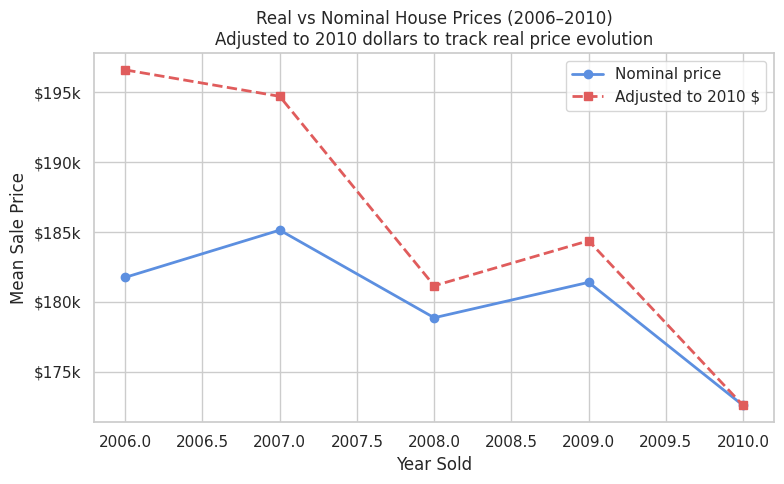

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
yearly = df.groupby("Year_Sold")[[TARGET, TARGET_ADJ]].mean()
ax.plot(yearly.index, yearly[TARGET],     marker="o", label="Nominal price",            color="#5c8fe0", linewidth=2)
ax.plot(yearly.index, yearly[TARGET_ADJ], marker="s", label=f"Adjusted to {BASE_YEAR} $", color="#e05c5c", linewidth=2, linestyle="--")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel("Year Sold")
ax.set_ylabel("Mean Sale Price")
ax.set_title("Real vs Nominal House Prices (2006–2010)\n"
             "Adjusted to 2010 dollars to track real price evolution")
ax.legend()
plt.tight_layout()
plt.show()

Chart 5 shows that nominal prices fell during the housing crash, dropping from a peak in 2007. In real (inflation-adjusted) terms the decline is steeper — particularly in 2008 when general inflation was still rising while house prices were already falling, meaning the real purchasing value of houses dropped more sharply than the nominal figures suggest. By 2010 the two lines converge because 2010 is the base year for the adjustment (factor = 1.0).